In [1]:
import pandas as pd
import numpy as np

# 1. Load the data we cleaned yesterday
df = pd.read_csv('C:\\Users\\Richard\\Downloads\\Semester break\\Processed\\ai4i2020_processed.csv')

print("Data loaded. Rows:", len(df))

Data loaded. Rows: 10000


In [2]:
# 2. Create Temperature Difference
# Insight: A higher delta suggests the machine is working hard or cooling is inefficient.
df['Temp_Delta'] = df['Process_Temp'] - df['Air_Temp']

# Sanity Check: Look at the distribution
print(df['Temp_Delta'].describe())

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temp_Delta, dtype: float64


In [3]:
# 3. Create Power Feature
# We calculate actual Power in Watts.
# Factor 0.1047 converts RPM to radians/second
df['Power_W'] = df['Torque'] * df['Rotational_Speed'] * 0.1047

# Check the first few rows to see your new creation
df[['Torque', 'Rotational_Speed', 'Power_W']].head()

,Torque,Rotational_Speed,Power_W
0,42.8,1551,6950.27916
1,46.3,1408,6825.43488
2,49.4,1498,7747.92564
3,39.5,1433,5926.38645
4,40.0,1408,5896.70400


In [4]:
# 4. Create a "Heuristic" metric
#  The "Risk Heuristic" (formerly Strain Index)
# Insight: A composite score. If Power is high AND Heat is high, risk multiplies.
# We call it a 'Heuristic' because W*K isn't a standard physical unit, but it works as a risk score.
df['Risk_Heuristic'] = df['Power_W'] * df['Temp_Delta']

In [7]:
print("\n--- Features Created ---")
print(df[['Temp_Delta', 'Power_W', 'Risk_Heuristic']].head())


--- Features Created ---
   Temp_Delta     Power_W  Risk_Heuristic
0        10.5  6950.27916    72977.931180
1        10.5  6825.43488    71667.066240
2        10.4  7747.92564    80578.426656
3        10.4  5926.38645    61634.419080
4        10.5  5896.70400    61915.392000


In [5]:
# Compare averages for Healthy (0) vs Broken (1) machines
print(df.groupby('Machine_Failure')[['Temp_Delta', 'Power_W', 'Risk_Heuristic']].mean())

                 Temp_Delta      Power_W  Risk_Heuristic
Machine_Failure                                         
0                 10.021571  6243.369516    62597.340766
1                  9.403835  7281.445600    68478.424145


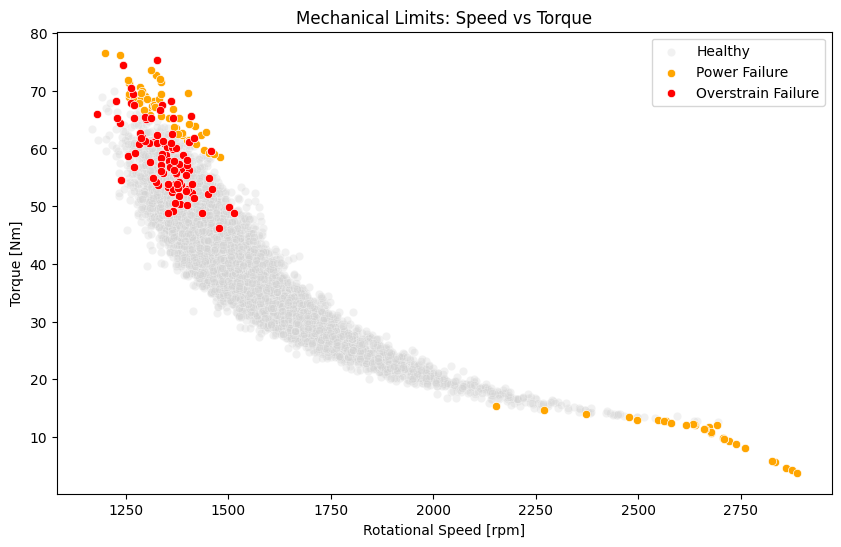

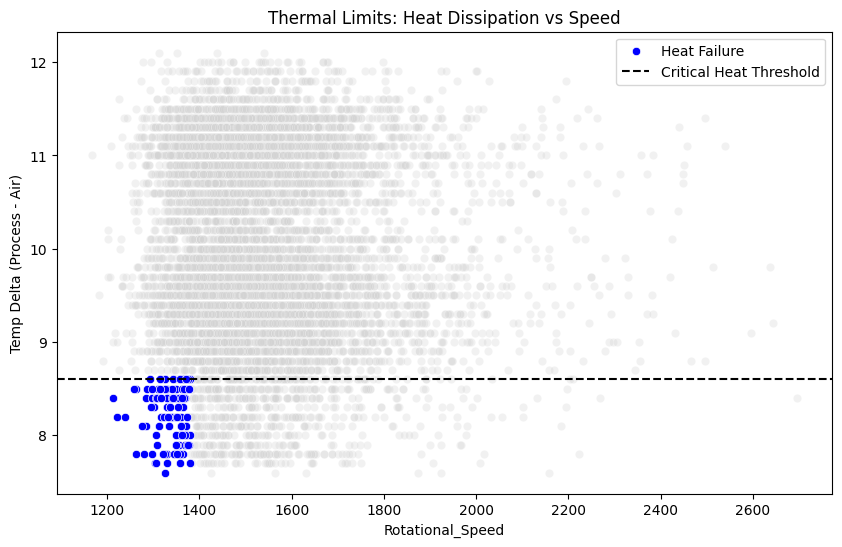

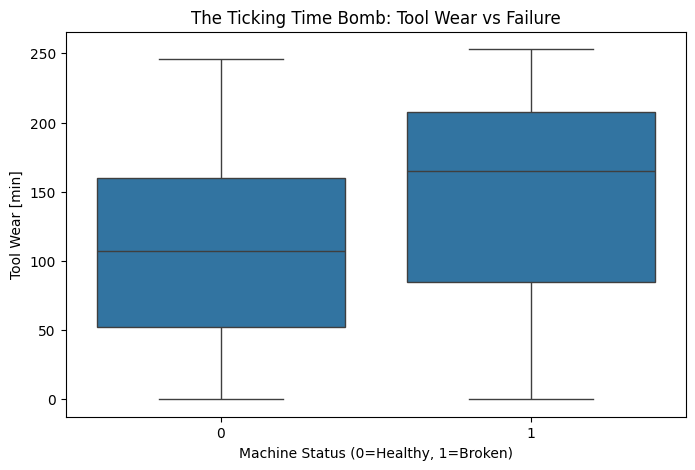

Minimum Tool Wear when TWF happens: 198 minutes


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3. VISUALIZATION: THE OPERATING ZONES
# ==========================================

# FIGURE 1: The "Operating Envelope" (Mechanics)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Machine_Failure']==0], x='Rotational_Speed', y='Torque', color='lightgrey', alpha=0.3, label='Healthy')
sns.scatterplot(data=df[df['Power_Failure']==1], x='Rotational_Speed', y='Torque', color='orange', label='Power Failure')
sns.scatterplot(data=df[df['Overstrain_Failure']==1], x='Rotational_Speed', y='Torque', color='red', label='Overstrain Failure')
plt.title('Mechanical Limits: Speed vs Torque')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.legend()
plt.show()

# FIGURE 2: Thermodynamics (Heat)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Machine_Failure']==0], x='Rotational_Speed', y='Temp_Delta', color='lightgrey', alpha=0.3)
sns.scatterplot(data=df[df['Heat_Dissipation_Failure']==1], x='Rotational_Speed', y='Temp_Delta', color='blue', label='Heat Failure')
plt.axhline(y=8.6, color='black', linestyle='--', label='Critical Heat Threshold')
plt.title('Thermal Limits: Heat Dissipation vs Speed')
plt.ylabel('Temp Delta (Process - Air)')
plt.legend()
plt.show()

# FIGURE 3: The "Ticking Time Bomb" (Tool Wear) - ADDED THIS BACK
# This confirms that Tool Wear is predictable (The Bathtub Curve)
twf_data = df[df['Tool_Wear_Failure'] == 1]['Tool_Wear']
plt.figure(figsize=(8, 5))
sns.boxplot(x='Machine_Failure', y='Tool_Wear', data=df)
plt.title("The Ticking Time Bomb: Tool Wear vs Failure")
plt.xlabel("Machine Status (0=Healthy, 1=Broken)")
plt.ylabel("Tool Wear [min]")
plt.show()
print(f"Minimum Tool Wear when TWF happens: {twf_data.min()} minutes")

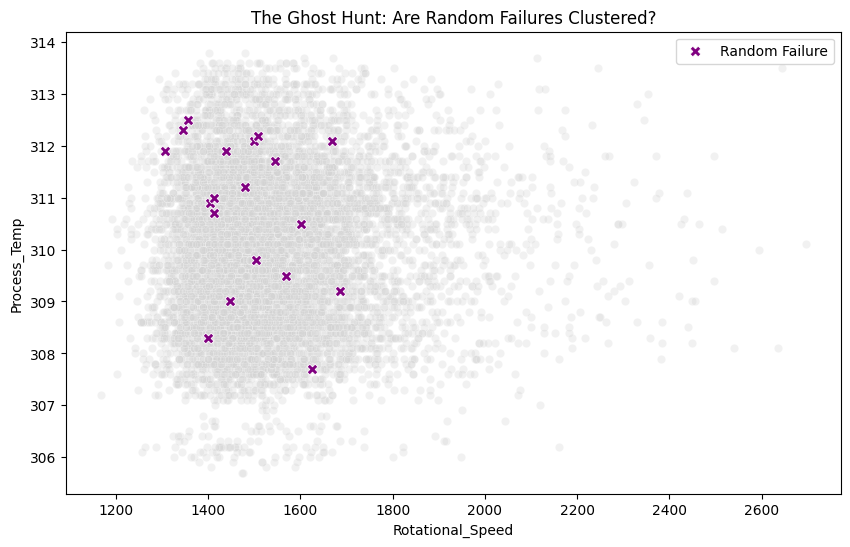

In [12]:
# ==========================================
# 4. THE GHOST HUNT (RNF) & SAVE
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Machine_Failure']==0], x='Rotational_Speed', y='Process_Temp', color='lightgrey', alpha=0.3)
# Correct column name: Random_Failure
sns.scatterplot(data=df[df['Random_Failure']==1], x='Rotational_Speed', y='Process_Temp', color='purple', marker='X', s=60, label='Random Failure')

plt.title("The Ghost Hunt: Are Random Failures Clustered?")
plt.legend()
plt.show()

In [13]:
# Save to a new file. We keep the versions distinct.
df.to_csv('C:\\Users\\Richard\\Downloads\\Semester break\\Processed\\ai4i2020_featured.csv', index=False)
print("Feature Engineering Complete. Saved as 'ai4i2020_featured.csv'")

Feature Engineering Complete. Saved as 'ai4i2020_featured.csv'
